In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sleep_df = pd.read_csv('/content/drive/MyDrive/sleeps.csv')
cycles_df = pd.read_csv('/content/drive/MyDrive/physiological_cycles.csv')

In [ ]:
merged_df = pd.merge(cycles_df, sleep_df, on='Cycle start time', suffixes=('_physio', '_sleep'))
merged_df.drop(index=0,inplace=True)

In [ ]:
complex_columns = [
    'Recovery score %',  # <- we want to make a model that estimates this variable using all the others
    'Resting heart rate (bpm)', 'Heart rate variability (ms)', 'Skin temp (celsius)',
    'Sleep efficiency %_physio', 'REM duration (min)_physio', 'Deep (SWS) duration (min)_physio',
    'Light sleep duration (min)_physio', 'Day Strain',
    'Average HR (bpm)', 'Sleep debt (min)_physio']

# Select only the specified columns from the merged dataset
data = merged_df[complex_columns]

# Drop any rows with missing values in the selected data to ensure model reliability
data.dropna(inplace=True)

<ipython-input-6-620242edf46d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [ ]:
# Trying my own model using linear algebra
X = data.drop(columns=['Recovery score %'])  # Features used for prediction
y = data['Recovery score %']  # Target variable

# Splitting the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Creating the coefficient matrix for the training data
train_coeff_matrix = np.matrix(np.zeros([len(list(X_train['Day Strain'])), 1 + len(list(X_train.columns))]))

# Populating the training coefficient matrix with a bias term and feature values
for i in range(len(list(X_train['Day Strain']))):
    train_coeff_matrix[i] = [1] + list(X_train.iloc[i])  # Adding a bias term (1)

# Converting the target variable to a matrix format
y_train_mat = np.matrix(np.zeros([len(list(y_train)), 1]))
for i in range(len(list(y_train))):
    y_train_mat[i] = [list(y_train)[i]]

# Calculating the coefficients for the model using linear algebra (least squares method)
complex_model = (((train_coeff_matrix.getT() * train_coeff_matrix).getI()) * (train_coeff_matrix.getT())) * y_train_mat

# Creating the coefficient matrix for the test data
test_coeff_matrix = np.matrix(np.zeros([len(list(X_test['Day Strain'])), 1 + len(list(X_test.columns))]))

# Populating the test coefficient matrix with a bias term and feature values
for i in range(len(list(X_test['Day Strain']))):
    test_coeff_matrix[i] = [1] + list(X_test.iloc[i])  # Adding a bias term (1)

# Generating predictions for the test set using the model
y_pred = test_coeff_matrix * complex_model

mse = mean_squared_error(y_test, np.asarray(y_pred))  # Mean Squared Error
mae = mean_absolute_error(y_test, np.asarray(y_pred))  # Mean Absolute Error
rmse = mse ** 0.5  # Root Mean Squared Error

mse, mae, rmse

(102.60650090081094, 7.720242569237069, 10.12948670470577)

In [ ]:
# Post-testing analysis
coeffs = ['bias'] + complex_columns[1:]
coeff_dict = {}

for i in range(len(coeffs)):
  coeff_dict[coeffs[i]] = complex_model.tolist()[i][0]

coeff_dict

{'bias': 0.3025656800098133,
 'Resting heart rate (bpm)': -0.23873354478657308,
 'Heart rate variability (ms)': 2.7291081796851695,
 'Skin temp (celsius)': -2.021446492016878,
 'Sleep efficiency %_physio': 0.010485238678721075,
 'REM duration (min)_physio': 0.03081802650135272,
 'Deep (SWS) duration (min)_physio': 0.168656784331045,
 'Light sleep duration (min)_physio': 0.03986705747685599,
 'Day Strain': 0.12227696366704809,
 'Average HR (bpm)': 0.29798170939089114,
 'Sleep debt (min)_physio': -0.030272759639719253}

In [ ]:
# Simpler model using only the top 5 most contributing factors
simple_columns = [
    'Recovery score %',
    'Skin temp (celsius)',
    'Average HR (bpm)',
    'Resting heart rate (bpm)',
    'Heart rate variability (ms)',
    'Light sleep duration (min)_physio']

data = merged_df[simple_columns]
data.dropna(inplace=True)

<ipython-input-9-f64e45d72ece>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [ ]:
X = data.drop(columns=['Recovery score %'])
y = data['Recovery score %']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

train_coeff_matrix = np.matrix(np.zeros([len(list(X_train['Skin temp (celsius)'])),1+len(list(X_train.columns))]))

for i in range(len(list(X_train['Skin temp (celsius)']))):
  train_coeff_matrix[i] = [1] + list(X_train.iloc[i])

y_train_mat = np.matrix(np.zeros([len(list(y_train)),1]))
for i in range(len(list(y_train))):
  y_train_mat[i] = [list(y_train)[i]]

simple_model = (((train_coeff_matrix.getT()*train_coeff_matrix).getI())*(train_coeff_matrix.getT()))*y_train_mat

test_coeff_matrix = np.matrix(np.zeros([len(list(X_test['Skin temp (celsius)'])),1+len(list(X_test.columns))]))
for i in range(len(list(X_test['Skin temp (celsius)']))):
  test_coeff_matrix[i] = [1] + list(X_test.iloc[i])

y_pred = test_coeff_matrix * simple_model


mse = mean_squared_error(y_test,np.asarray(y_pred)) # <- don't really care about this one
mae = mean_absolute_error(y_test,np.asarray(y_pred))
rmse = mse**0.5

mse,mae,rmse

(111.62906627166824, 8.076443703280603, 10.565465738511874)

#Garret Testing

In [ ]:
g_sleep_df = pd.read_csv('/content/drive/MyDrive/Garrett_sleeps.csv')
g_cycles_df = pd.read_csv('/content/drive/MyDrive/Garrett_physiological_cycles.csv')

In [ ]:
g_merged_df = pd.merge(g_cycles_df, g_sleep_df, on='Cycle start time', suffixes=('_physio', '_sleep'))
g_merged_df.drop(index=0,inplace=True)

In [ ]:
g_data = g_merged_df[complex_columns]
g_data.dropna(inplace=True)

<ipython-input-20-8eec256753bf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g_data.dropna(inplace=True)


In [ ]:
g_X = g_data.drop(columns=['Recovery score %'])
g_y = g_data['Recovery score %']

g_test_coeff_matrix = np.matrix(np.zeros([len(list(g_X['Day Strain'])),1+len(list(g_X.columns))]))
for i in range(len(list(g_X['Day Strain']))):
  g_test_coeff_matrix[i] = [1] + list(g_X.iloc[i])

g_y_pred = g_test_coeff_matrix * complex_model

g_mse = mean_squared_error(g_y,np.asarray(g_y_pred)) # <- don't really care about this one
g_mae = mean_absolute_error(g_y,np.asarray(g_y_pred))
g_rmse = g_mse**0.5

g_mse,g_mae,g_rmse

(46454.57540306624, 214.4585739306189, 215.53323503132003)

#Visualizations

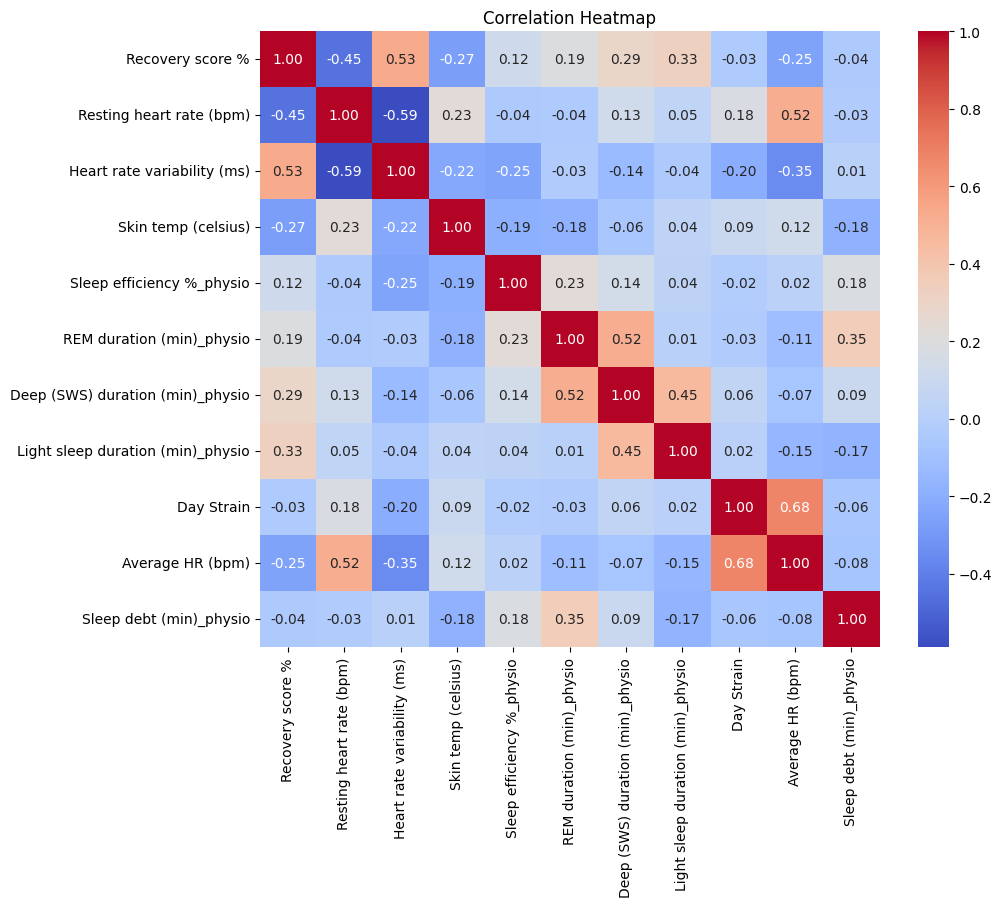

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = merged_df[complex_columns].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


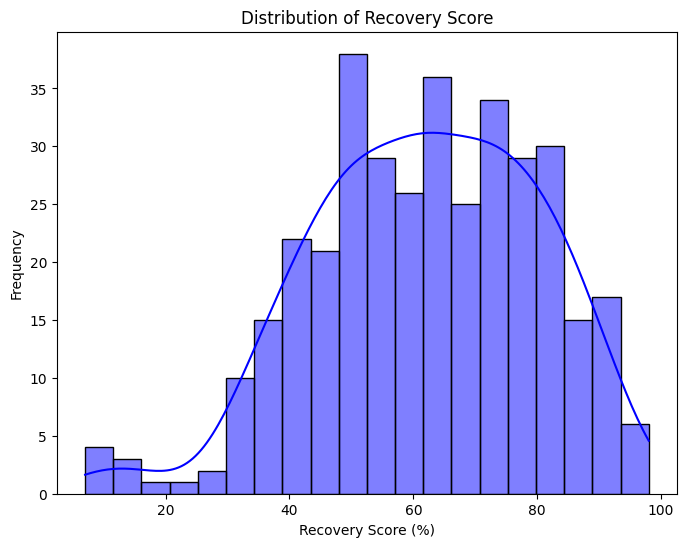

In [ ]:
# Plot histogram for Recovery Score
plt.figure(figsize=(8, 6))
sns.histplot(data['Recovery score %'], kde=True, bins=20, color='blue')
plt.title("Distribution of Recovery Score")
plt.xlabel("Recovery Score (%)")
plt.ylabel("Frequency")
plt.show()


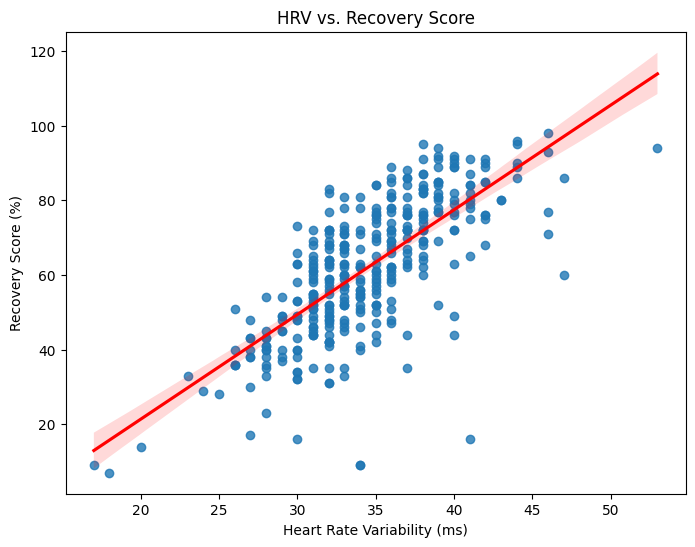

In [ ]:
# Scatter plot of HRV vs. Recovery Score with line of best fit
plt.figure(figsize=(8, 6))
sns.regplot(x=data['Heart rate variability (ms)'], y=data['Recovery score %'], scatter=True, line_kws={"color": "red"})
plt.title("HRV vs. Recovery Score")
plt.xlabel("Heart Rate Variability (ms)")
plt.ylabel("Recovery Score (%)")
plt.show()


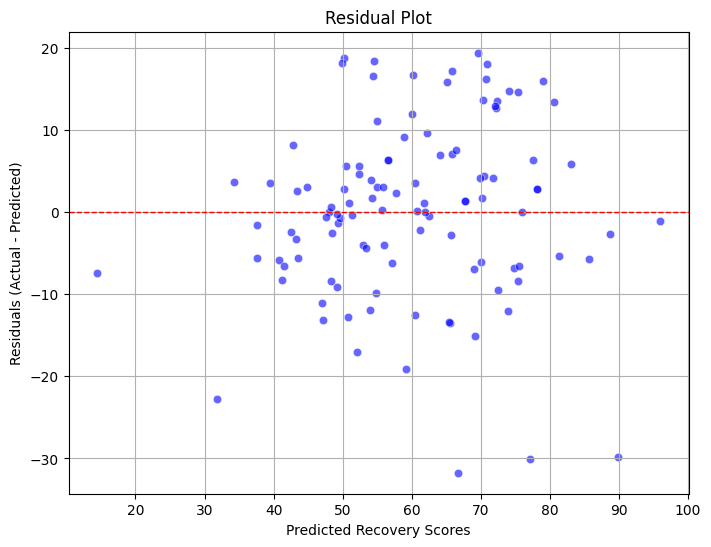

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals = y_test - np.asarray(y_pred).flatten()

# Create residual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=np.asarray(y_pred).flatten(), y=residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title("Residual Plot")
plt.xlabel("Predicted Recovery Scores")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True)
plt.show()
